# Heat stress indices

*Varunayan: ERA5 climate data for Python*

Air temperature alone does not capture heat stress well. Humidity limits the
body's cooling through sweating, and wind and solar radiation change the load,
so two days at the same temperature can differ greatly in physiological risk.

This notebook shows how to compute and compare the heat-stress indices that
`varunayan` provides, and how to pull them straight from ERA5 in one call. We
cover:

- **Air temperature (T)**: standard 2 m temperature
- **Wet bulb temperature (Tw)**: Stull (2011), evaporative-cooling limit
- **Heat index (HI)**: NWS Rothfusz apparent temperature
- **WBGT**: Wet Bulb Globe Temperature (occupational standard, BoM closed form)
- **UTCI**: Universal Thermal Climate Index (Bröde 2012)
- **Humidex**: Canadian heat-discomfort index

| Index | Inputs | Primary use |
|-------|--------|-------------|
| Temperature | T | baseline |
| Wet bulb | T + humidity | physiological limit |
| Heat index | T + RH | public weather alerts |
| WBGT | T + humidity | workplace safety |
| UTCI | T + Tmrt + wind + humidity | climate / comfort research |
| Humidex | T + dewpoint | Canadian weather |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import varunayan as v
from varunayan.heat_stress import (
    relative_humidity_from_dewpoint, wet_bulb_temperature, heat_index,
    wbgt_simple, humidex, mean_radiant_temperature, utci,
    heat_index_risk_category, wbgt_risk_category, utci_category,
)

✓ CDS API configuration is already set up and valid.


## 1. The indices on a controlled grid

Before touching real data, let's see how each index responds to temperature and
humidity. We sweep air temperature at three fixed relative-humidity levels and
plot the apparent-temperature indices against the dry-bulb baseline.


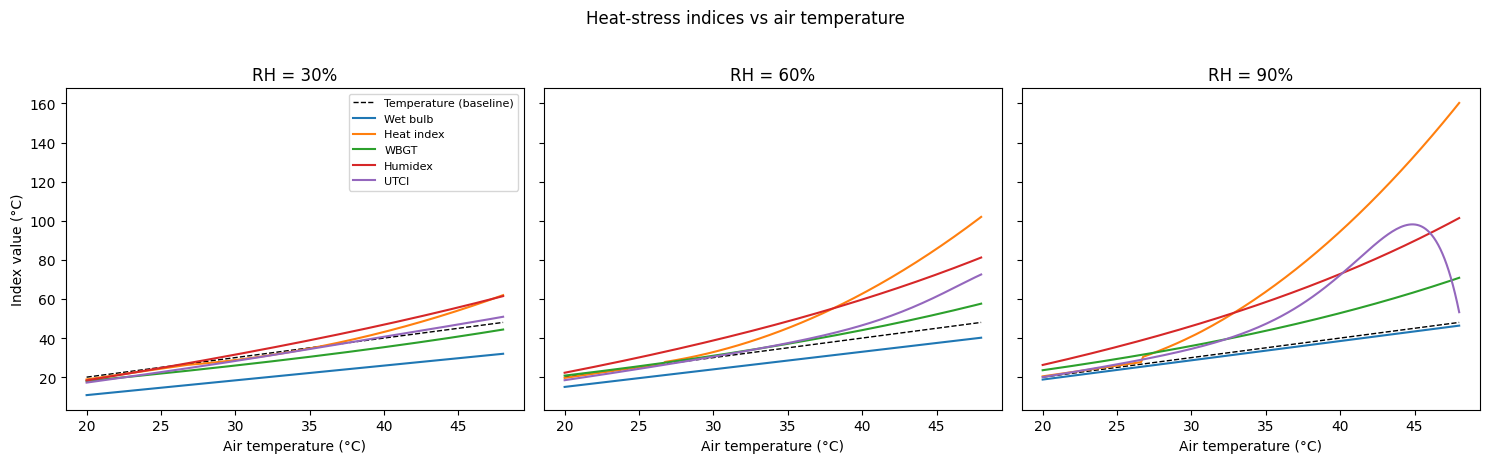

In [2]:
T = np.linspace(20, 48, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, rh_level in zip(axes, [30, 60, 90]):
    # dewpoint that yields the target RH at each T (invert Magnus)
    a, b = 17.625, 243.04
    gamma = np.log(rh_level / 100) + a * T / (b + T)
    Td = b * gamma / (a - gamma)
    rh = relative_humidity_from_dewpoint(T, Td)

    ax.plot(T, T, "k--", lw=1, label="Temperature (baseline)")
    ax.plot(T, wet_bulb_temperature(T, rh), label="Wet bulb")
    ax.plot(T, heat_index(T, rh), label="Heat index")
    ax.plot(T, wbgt_simple(T, Td), label="WBGT")
    ax.plot(T, humidex(T, Td), label="Humidex")
    ax.plot(T, utci(T, rh, 2.0, None), label="UTCI")
    ax.set_title(f"RH = {rh_level}%")
    ax.set_xlabel("Air temperature (°C)")
axes[0].set_ylabel("Index value (°C)")
axes[0].legend(fontsize=8)
fig.suptitle("Heat-stress indices vs air temperature", y=1.02)
fig.tight_layout()
plt.show()

Observations:

- **Wet bulb** is always *below* air temperature (evaporative cooling).
- **Heat index** and **humidex** climb above air temperature as humidity rises.
- At low RH the heat index can sit *below* the dry-bulb line. Dry heat feels
  less severe than the thermometer reads.
- **UTCI** and **WBGT** fold humidity (and, for UTCI, wind) into a single
  effective temperature.


## 2. Risk categories

Each index maps to a categorical risk scale. `varunayan` uses the canonical
thresholds: NWS heat-index categories (80/90/103/124 °F), the NWS/OSHA WBGT
flag conditions (78/82/85/88 °F), and the standard 10-level UTCI assessment
scale (Bröde 2012).


In [3]:
sample = pd.DataFrame({"temp_c": [22, 28, 34, 40, 46], "dewpoint_c": [12, 20, 26, 30, 34]})
Tv, Tdv = sample["temp_c"].values, sample["dewpoint_c"].values
sample["rh"] = relative_humidity_from_dewpoint(Tv, Tdv)
sample["heat_index"] = heat_index(Tv, sample["rh"].values)
sample["wbgt"] = wbgt_simple(Tv, Tdv)
sample["utci"] = utci(Tv, sample["rh"].values, 2.0, None)
sample["HI risk"] = heat_index_risk_category(sample.heat_index.values)
sample["WBGT risk"] = wbgt_risk_category(sample.wbgt.values)
sample["UTCI stress"] = utci_category(sample.utci.values)
sample.round(1)

,temp_c,dewpoint_c,rh,heat_index,wbgt,utci,HI risk,WBGT risk,UTCI stress
0,22,12,53.1,21.6,21.9,20.3,Normal,Low,No Thermal Stress
1,28,20,61.8,29.7,29.0,28.1,Caution,High,Moderate Heat Stress
2,34,26,63.1,43.5,36.4,36.4,Danger,Extreme,Strong Heat Stress
3,40,30,57.4,60.5,43.3,45.5,Extreme Danger,Extreme,Very Strong Heat Stress
4,46,34,52.6,80.9,51.0,57.8,Extreme Danger,Extreme,Extreme Heat Stress


## 3. From ERA5 in one call

`get_era5_daily_heat_index_data` downloads temperature, dewpoint, and wind
(plus solar radiation when `solar_load=True`) for a region and returns every
index already computed. This mirrors the R package's `GetERA5DailyHeatIndexData`.

> Running the next cell needs CDS API credentials configured (see the
> quickstart notebook). It downloads real ERA5 data and takes a few minutes, so
> it is left un-run here. The cells after it work on whatever it returns.


In [4]:
# Requires CDS API credentials. Downloads India, May 2023, daily.
RUN_DOWNLOAD = False  # set True if you have CDS credentials configured

if RUN_DOWNLOAD:
    states_geojson = "indian_states.geojson"  # path to a region GeoJSON
    heat_solar = v.get_era5_daily_heat_index_geojson(
        request_id="india_heat_may2023_solar",
        start_date="2023-05-01",
        end_date="2023-05-31",
        geojson_file=states_geojson,
        solar_load=True,
    )
    heat_solar.head()

## 4. Solar load impact

With `solar_load=True` the function downloads solar radiation, estimates the
mean radiant temperature (Thorsson 2007), and feeds it into UTCI / WBGT so the
indices reflect direct sun rather than shade. The radiant load can add several
degrees. We illustrate the effect synthetically here (no download required).


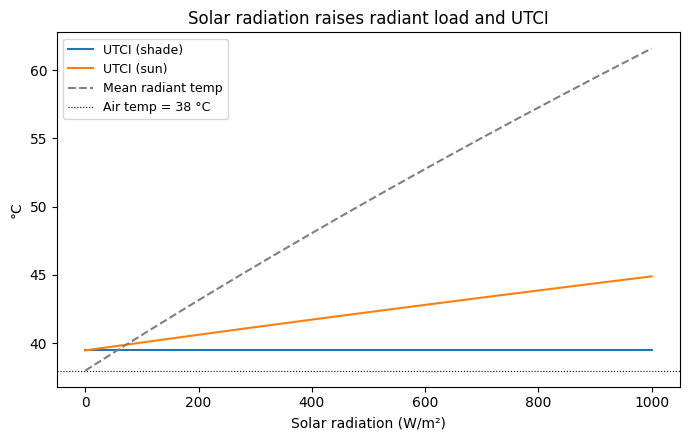

In [5]:
T = np.full(200, 38.0)
Td = np.full(200, 24.0)
ws = np.full(200, 2.0)
S = np.linspace(0, 1000, 200)  # global horizontal irradiance, W/m^2
rh = relative_humidity_from_dewpoint(T, Td)
mrt = mean_radiant_temperature(T, S)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(S, utci(T, rh, ws, None), label="UTCI (shade)")
ax.plot(S, utci(T, rh, ws, mrt), label="UTCI (sun)")
ax.plot(S, mrt, "--", color="grey", label="Mean radiant temp")
ax.axhline(38, color="k", lw=0.8, ls=":", label="Air temp = 38 °C")
ax.set_xlabel("Solar radiation (W/m²)")
ax.set_ylabel("°C")
ax.set_title("Solar radiation raises radiant load and UTCI")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 5. Relationship between indices

On a realistic spread of conditions, the indices correlate strongly but not
perfectly. Each captures a different facet of heat stress. The correlation
heatmap below is computed on a synthetic but realistic ensemble.


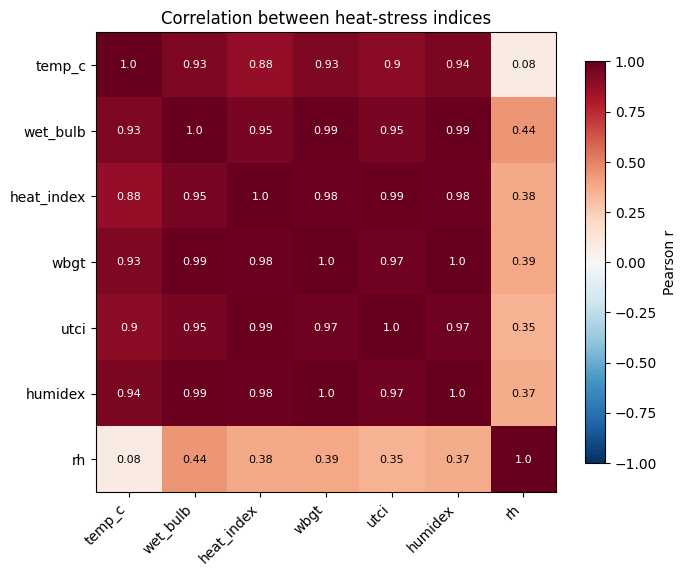

In [6]:
rng = np.random.default_rng(42)
n = 3000
T = rng.uniform(20, 46, n)
Td = T - rng.uniform(2, 18, n)
ws = rng.uniform(0.5, 8, n)
rh = relative_humidity_from_dewpoint(T, Td)
df = pd.DataFrame({
    "temp_c": T,
    "wet_bulb": wet_bulb_temperature(T, rh),
    "heat_index": heat_index(T, rh),
    "wbgt": wbgt_simple(T, Td),
    "utci": utci(T, rh, ws, None),
    "humidex": humidex(T, Td),
    "rh": rh,
})
corr = df.corr().round(2)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, corr.iloc[i, j], ha="center", va="center",
                color="white" if abs(corr.iloc[i, j]) > 0.5 else "black", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Correlation between heat-stress indices")
fig.tight_layout()
plt.show()

## 6. Cross-checking against the R package

`varunayan` (Python) and [`varunayanR`](https://github.com/saketkc/varunayanR)
implement the same canonical formulas. The indices are validated to be
numerically identical across both languages. The benchmark below regenerates a
shared input grid, runs both implementations, and reports per-index agreement.

> This cell shells out to `Rscript` and needs R + the `varunayanR` source
> checked out alongside this repo. It is informational; skip it if R is not
> installed.


In [7]:
import subprocess, sys
from pathlib import Path

bench = Path("..").resolve() / "benchmarks" / "compare_heat_indices.py"
if bench.exists():
    out = subprocess.run([sys.executable, str(bench)], capture_output=True, text=True)
    print(out.stdout or out.stderr)
else:
    print("benchmark script not found; see benchmarks/compare_heat_indices.py")

✓ CDS API configuration is already set up and valid.

=== Heat-stress indices: Python varunayan vs R varunayanR (n=5000) ===

Numeric indices:
  rh             max|d|=  9.948e-14   within 1e-06: 100.00%   -> IDENTICAL
  wet_bulb       max|d|=  6.395e-14   within 1e-06: 100.00%   -> IDENTICAL
  heat_index     max|d|=  5.826e-13   within 1e-06: 100.00%   -> IDENTICAL
  wbgt           max|d|=  5.684e-14   within 1e-06: 100.00%   -> IDENTICAL
  humidex        max|d|=  4.405e-13   within 1e-06: 100.00%   -> IDENTICAL
  mrt            max|d|=  1.066e-13   within 1e-06: 100.00%   -> IDENTICAL
  utci (shade)   max|d|=  1.957e-11   within 1e-06: 100.00%   -> IDENTICAL
  utci (solar)   max|d|=  1.828e-11   within 1e-06: 100.00%   -> IDENTICAL

Risk categories:
  hi_risk        label agreement: 100.00%   -> IDENTICAL
  wbgt_risk      label agreement: 100.00%   -> IDENTICAL
  utci_stress    label agreement: 100.00%   -> IDENTICAL

RESULT: all heat-stress indices are IDENTICAL across Python and R.


Every numeric index agrees to floating-point tolerance and every risk
category matches exactly, so analyses are reproducible whether you work in
Python or R.

### References

- Stull (2011), *J. Appl. Meteorol. Climatol.* 50:2267–2269. Wet bulb.
- Rothfusz (1990), NWS SR/SSD 90-23. Heat index.
- Bröde et al. (2012), *Int. J. Biometeorol.* 56:481–494. UTCI.
- Thorsson et al. (2007), *Int. J. Climatol.* 27:1983–1993. Mean radiant temp.
- Masterson & Richardson (1979), Environment Canada. Humidex.
- Australian Bureau of Meteorology. WBGT approximation.
